In [79]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
pickels = glob.glob('results/*pkl')

df_list = []

for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)

In [6]:
df.head()

,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,circularity,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment
0,"[[False, False, False, False, False, False, Fa...",27494,"[210, 170, 188, 184]",1.019673,"[[379.66666666666663, 232.55555555555554]]",0.993511,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",749,27494.0,0.914841,93.550051,"(379.66666666666663, 232.55555555555554)",189.256440,183.140656,111.661299,110.389060,216.105974,Tina 01,Tina
1,"[[False, False, False, False, False, False, Fa...",27255,"[232, 372, 186, 180]",1.014682,"[[334.99999999999994, 406.30555555555554]]",0.992509,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",737,27255.0,0.911201,93.142557,"(334.99999999999994, 406.30555555555554)",191.908833,180.000000,113.226211,109.908217,212.400000,Tina 01,Tina
2,"[[False, False, False, False, False, False, Fa...",29272,"[858, 593, 191, 192]",1.018185,"[[945.4166666666667, 692.0833333333334]]",0.992649,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",771,29272.0,0.906171,96.527545,"(945.4166666666667, 692.0833333333334)",195.645087,190.065765,115.430601,113.902503,224.277603,Tina 01,Tina
3,"[[False, False, False, False, False, False, Fa...",29319,"[473, 585, 192, 193]",1.012717,"[[513.6666666666666, 656.3611111111111]]",0.991783,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",775,29319.0,0.904582,96.605008,"(513.6666666666666, 656.3611111111111)",196.086716,192.000000,115.691162,113.993909,226.560000,Tina 01,Tina
4,"[[False, False, False, False, False, False, Fa...",29222,"[610, 374, 196, 189]",1.015703,"[[633.1388888888889, 406.30555555555554]]",0.990733,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",775,29222.0,0.903247,96.445070,"(633.1388888888889, 406.30555555555554)",199.180822,189.525040,117.516685,113.805182,223.639547,Tina 01,Tina


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='nm_feret_radius', ylabel='Count'>

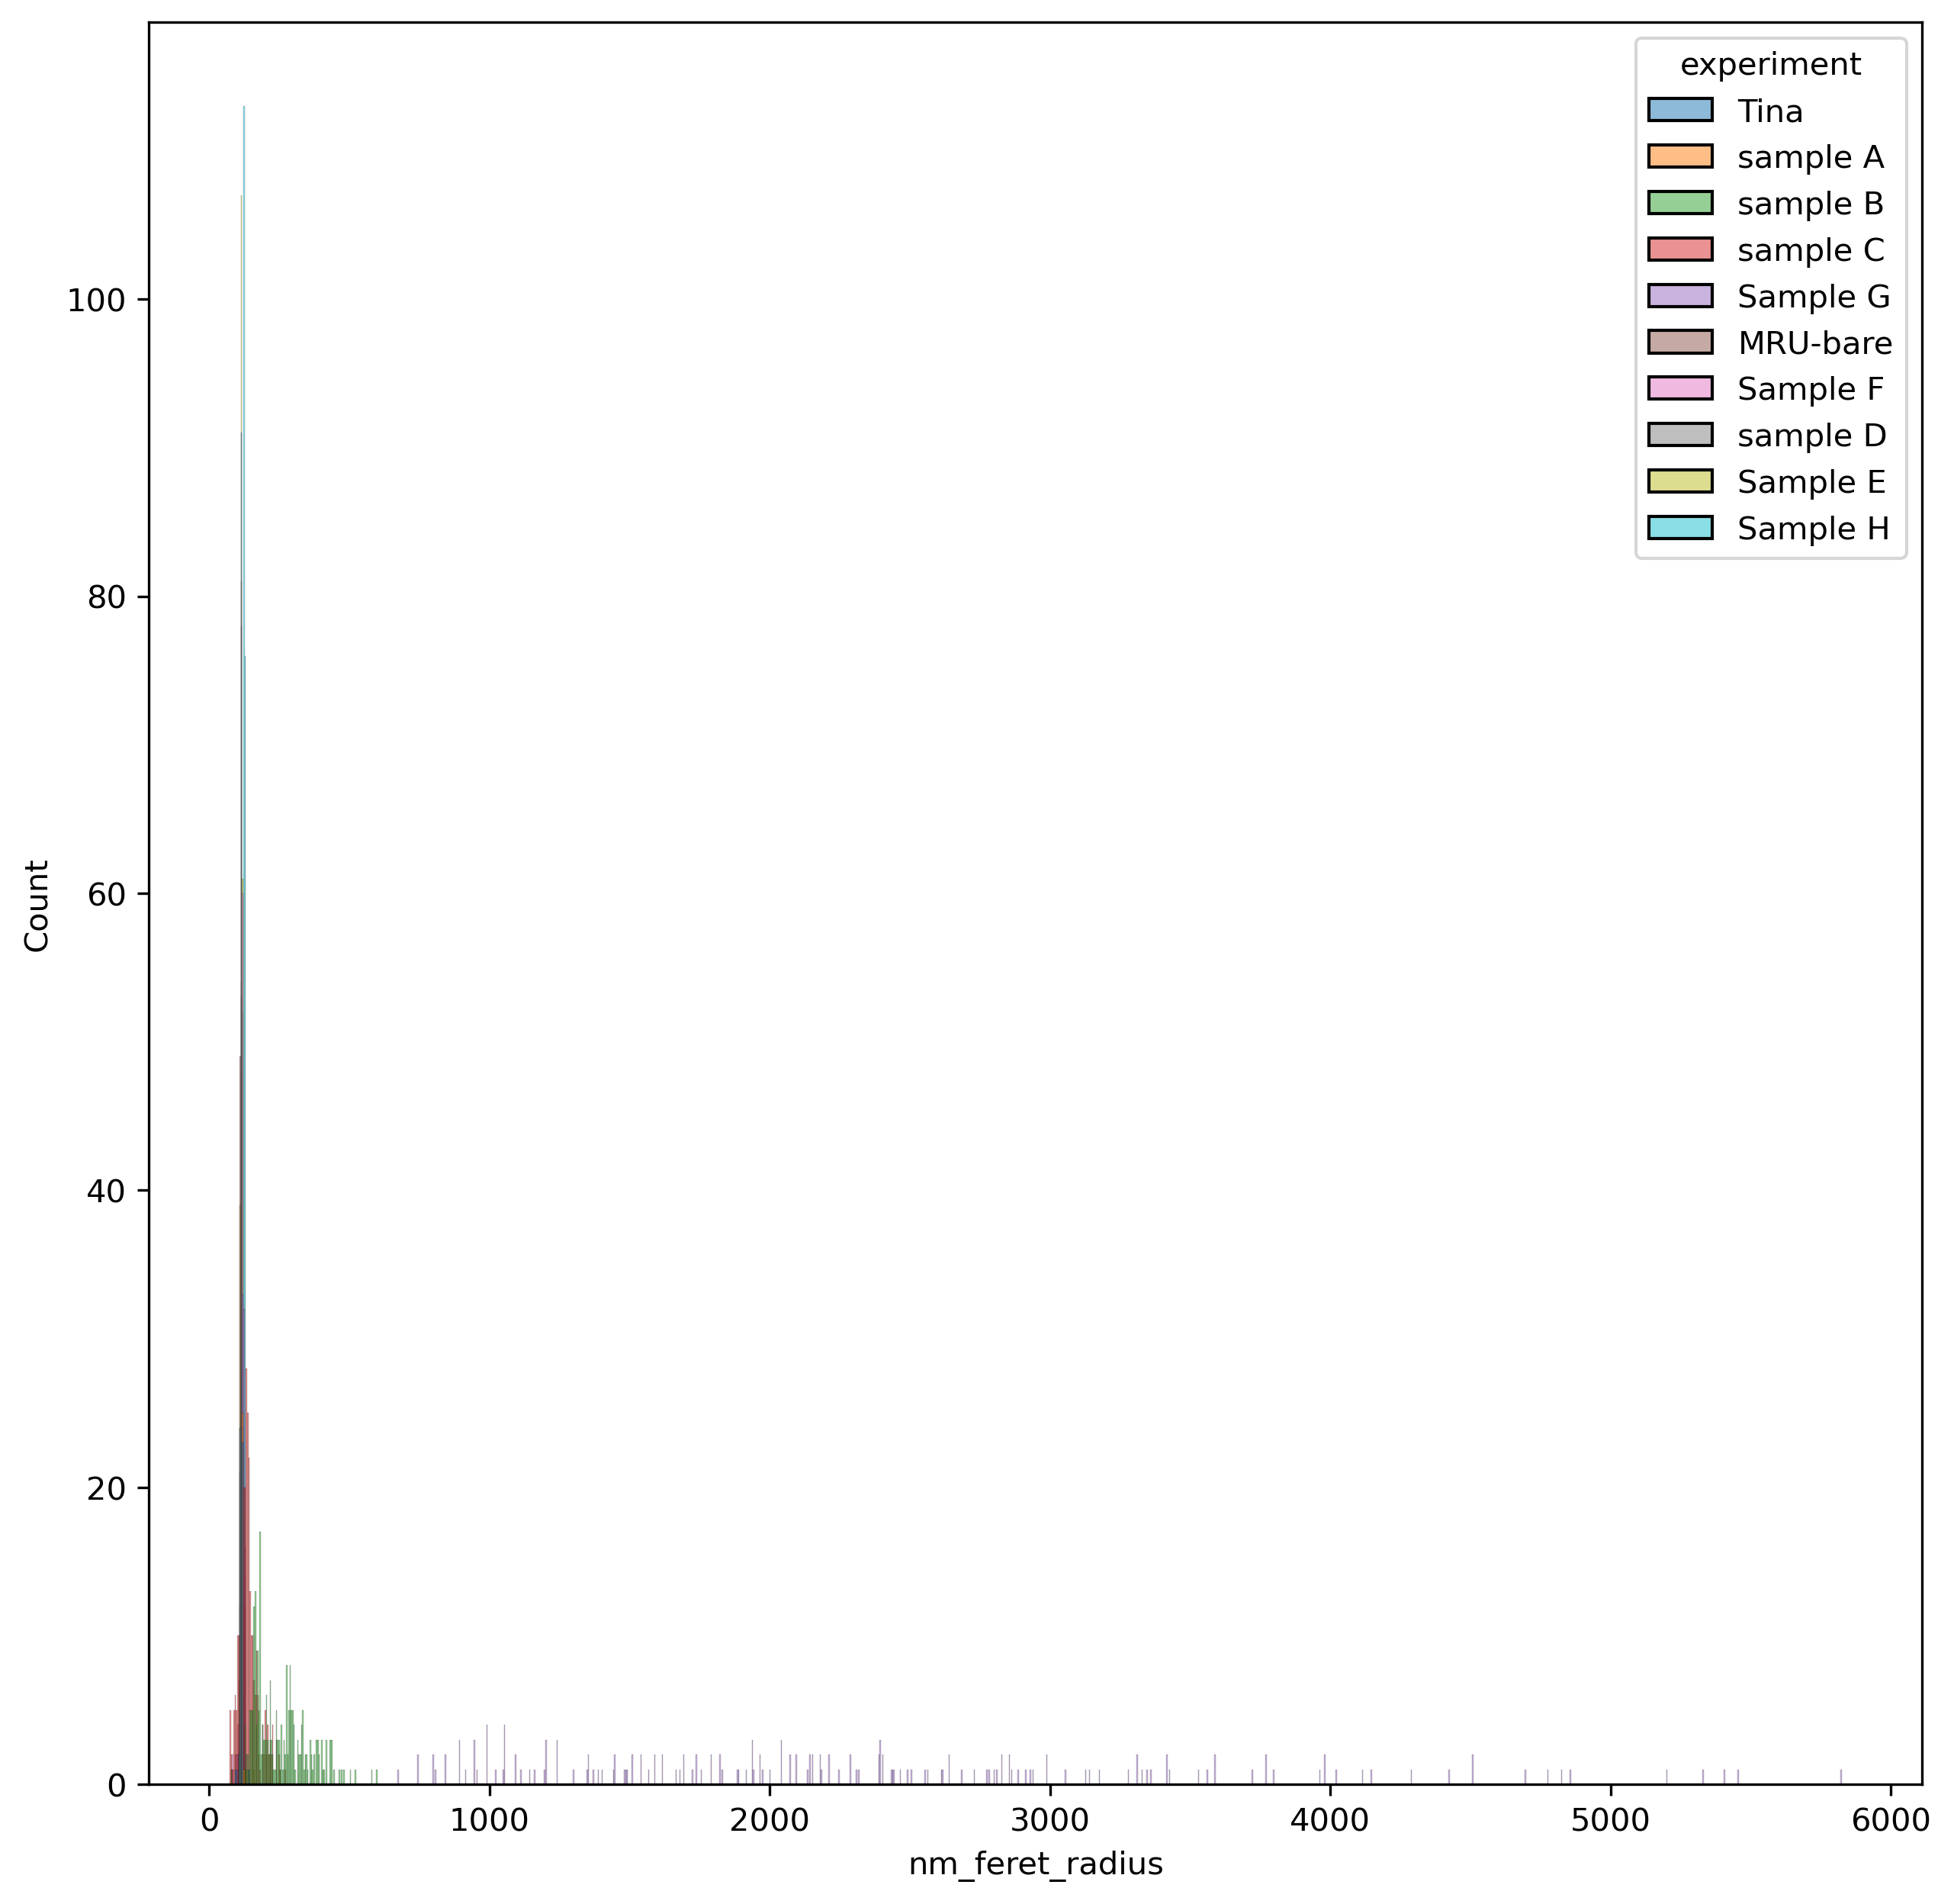

In [7]:
plt.figure(figsize=(10,10), dpi=300)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment')

In [8]:
exclusion_list = df[df.nm_feret_radius > 250].img_name.unique().tolist() + ['H-7']

In [9]:
df_filtered = df[~df['img_name'].isin(exclusion_list)]

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='nm_feret_radius', ylabel='Count'>

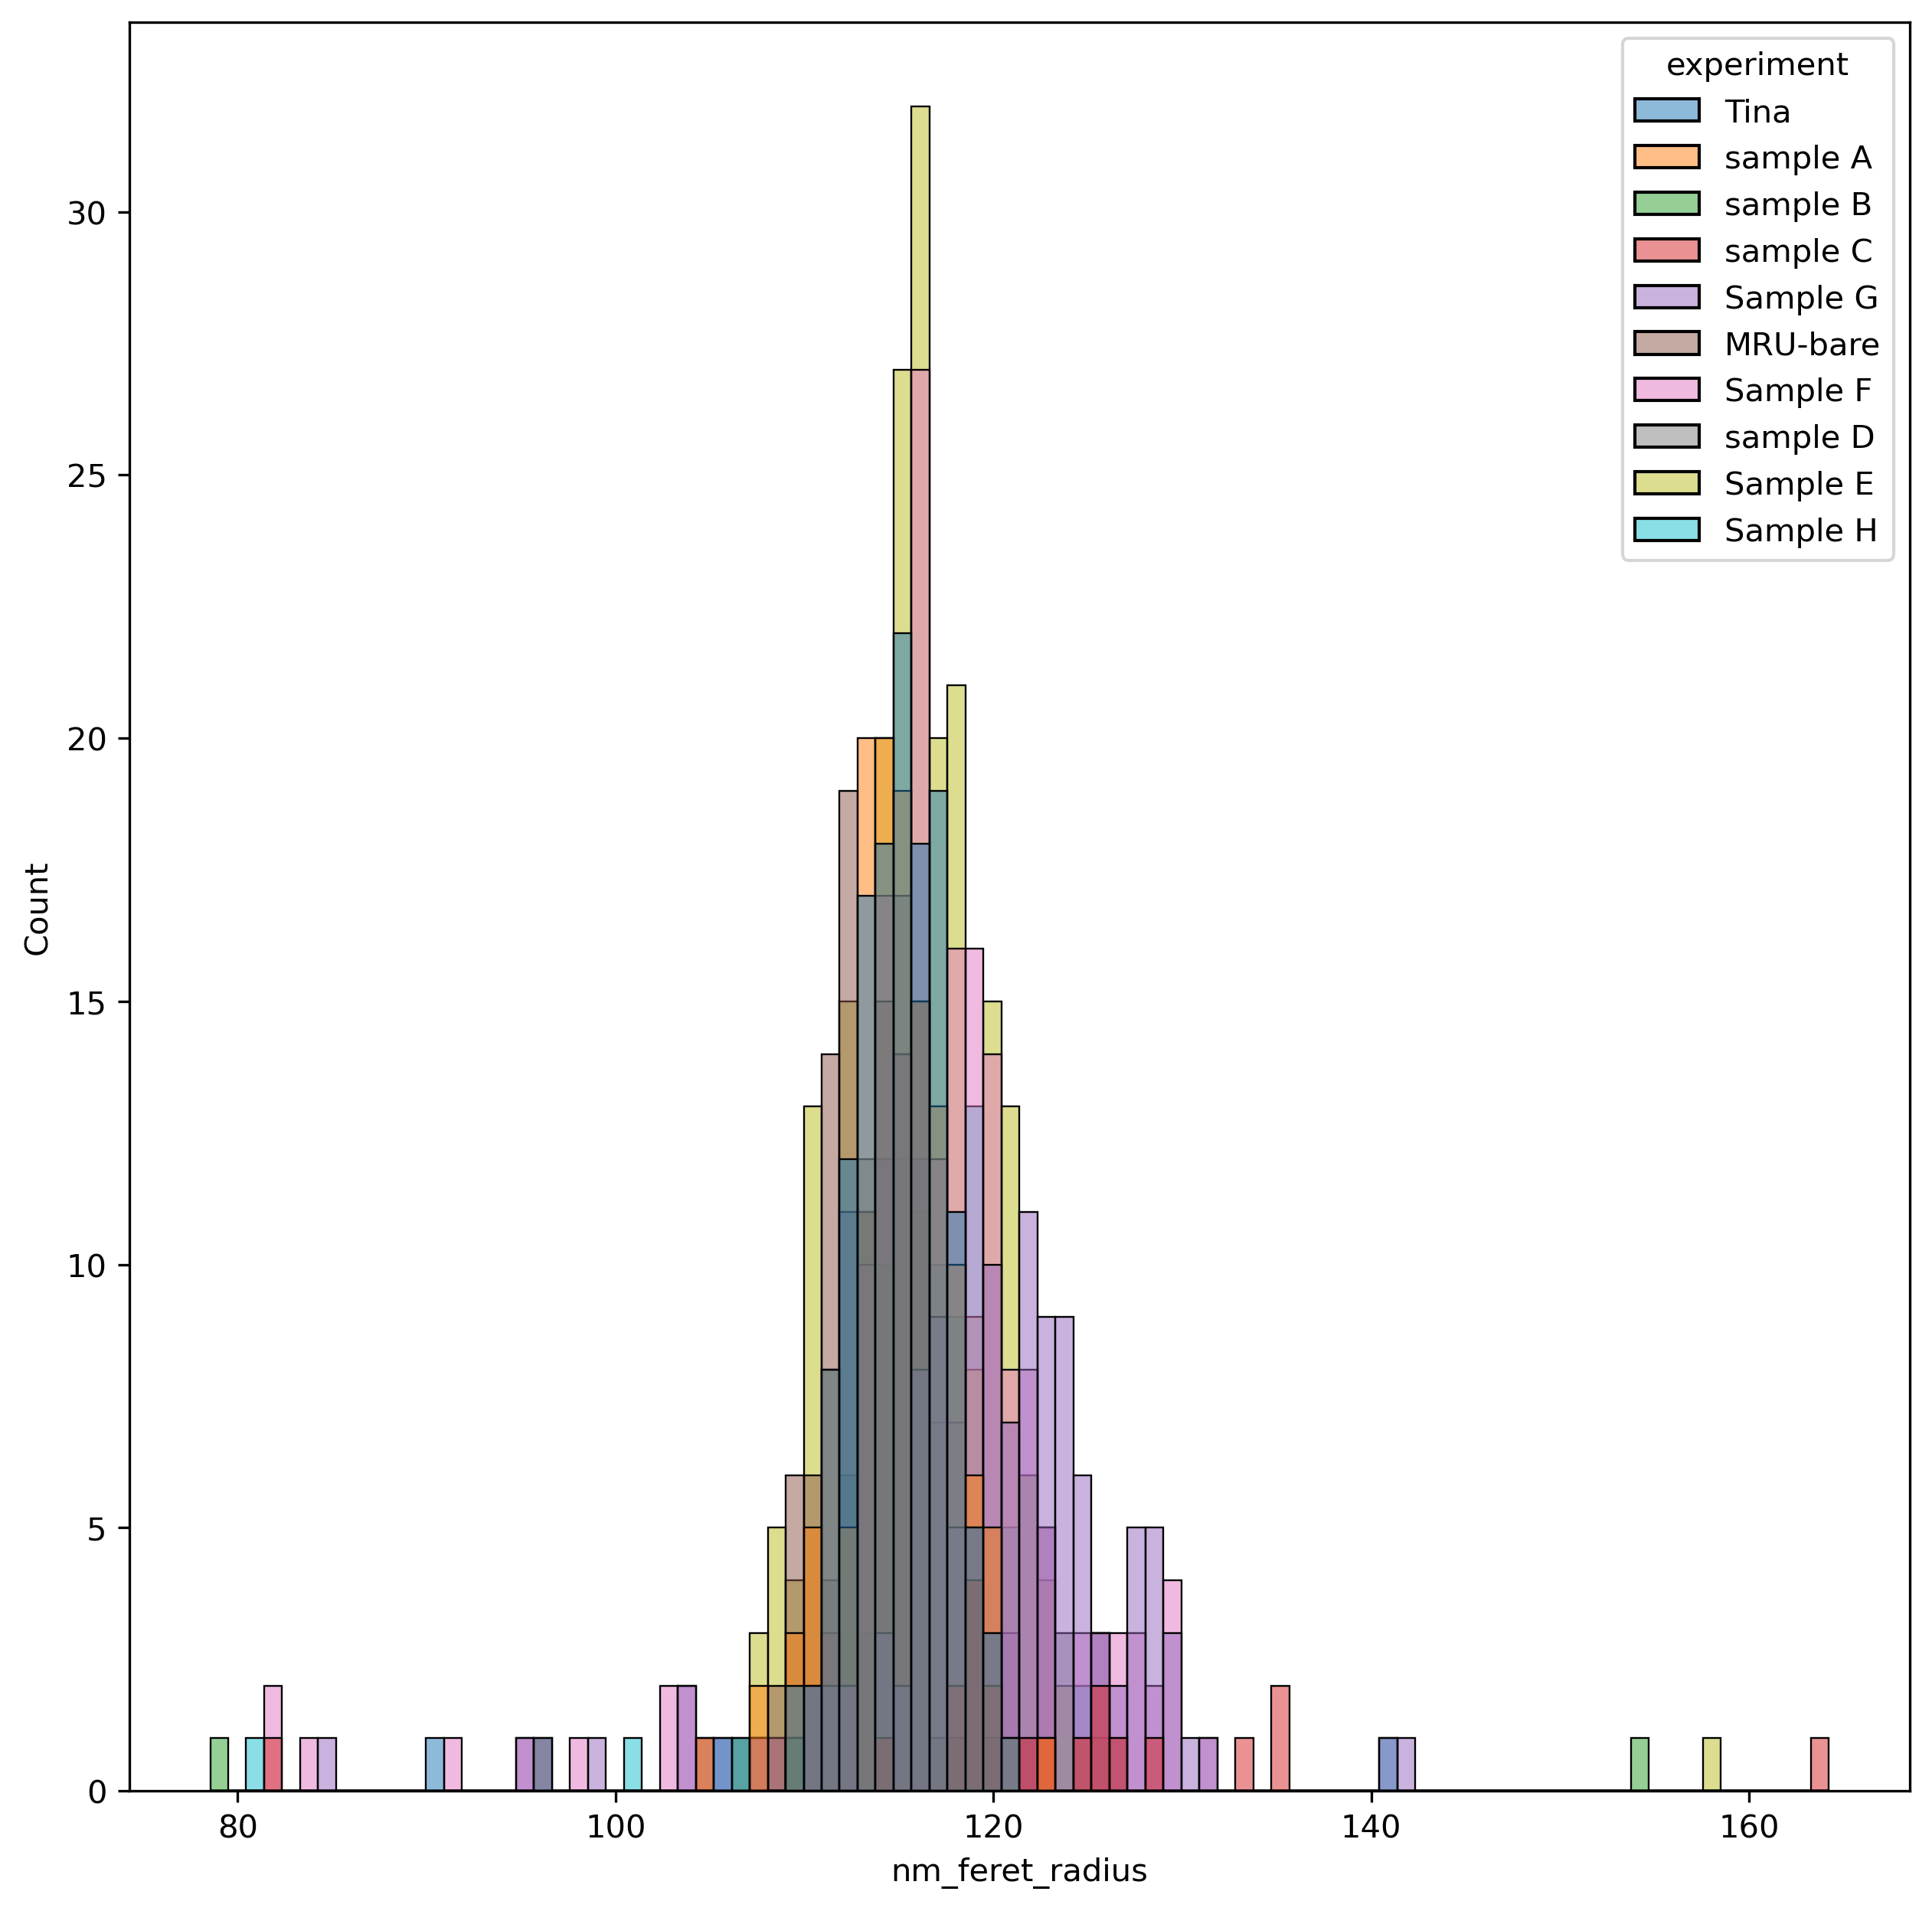

In [ ]:
plt.figure(figsize=(10,10), dpi=300)
sns.histplot(data=df_filtered, x='nm_feret_radius', hue='experiment')

In [118]:
q95

124.95860754665922

In [2]:
from NanoparticlesSAM import particle_stats as ps

In [40]:
df_filtered.columns

Index(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords',
       'stability_score', 'crop_box', 'smooth_mask', 'perimeter',
       'smooth_area', 'circularity', 'estimated_radius', 'point_coords_tuple',
       'feret_diameter', 'min_feret_diameter', 'nm_feret_radius',
       'nm_estimated_radius', 'nm_min_feret_diameter', 'img_name',
       'experiment'],
      dtype='object')

In [114]:
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values='nm_feret_radius')
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
experiment_df.head()

experiment,MRU-bare,Sample E,Sample F,Sample G,Sample H,Tina,sample A,sample B,sample C,sample D
0,114.712145,114.796559,116.180893,122.502360,114.856541,111.661299,115.805723,153.859627,118.457798,113.870541
1,115.003093,110.599503,120.300665,123.391436,116.433064,113.226211,113.795120,78.549185,124.463850,122.193494
2,115.050000,116.422721,116.689760,124.214167,122.245836,115.430601,116.266123,106.360237,123.014227,116.297033
3,115.864043,116.501073,117.091844,127.714861,119.218282,115.691162,116.974087,109.024080,118.964280,111.018017
4,116.481302,112.207397,115.732450,124.060738,115.101479,117.516685,122.548998,NaN,164.220888,120.130138


In [115]:
analyze_samples(experiment_df, 'MRU-bare', alpha=0.02)

,Sample E,Sample F,Sample G,Sample H,Tina,sample A,sample B,sample C,sample D
thickness,2.585942,3.398943,6.442556,2.732073,1.37476,1.416681,-1.57461,7.891144,2.733392
SEM,0.382891,0.584354,0.708004,0.555258,0.421093,0.333124,15.579074,3.185187,0.42612
CI_lower,1.690853,2.030687,4.777233,1.425407,0.388425,0.636474,-72.289203,-0.091698,1.733805
CI_upper,3.48103,4.767199,8.107879,4.038739,2.361094,2.196888,69.139983,15.873986,3.73298
p_value,0.0,0.0,0.0,0.000002,0.001259,0.00003,0.925867,0.021299,0.0
significance,Significant,Significant,Significant,Significant,Significant,Significant,Not significant,Not significant,Significant
significance_level,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0
DOF,329.695069,247.866364,146.123112,140.08785,235.010672,238.428796,3.001346,22.237792,193.361074
N_sample,226,187,119,100,143,133,4,23,114
N_ref,109,109,109,109,109,109,109,109,109


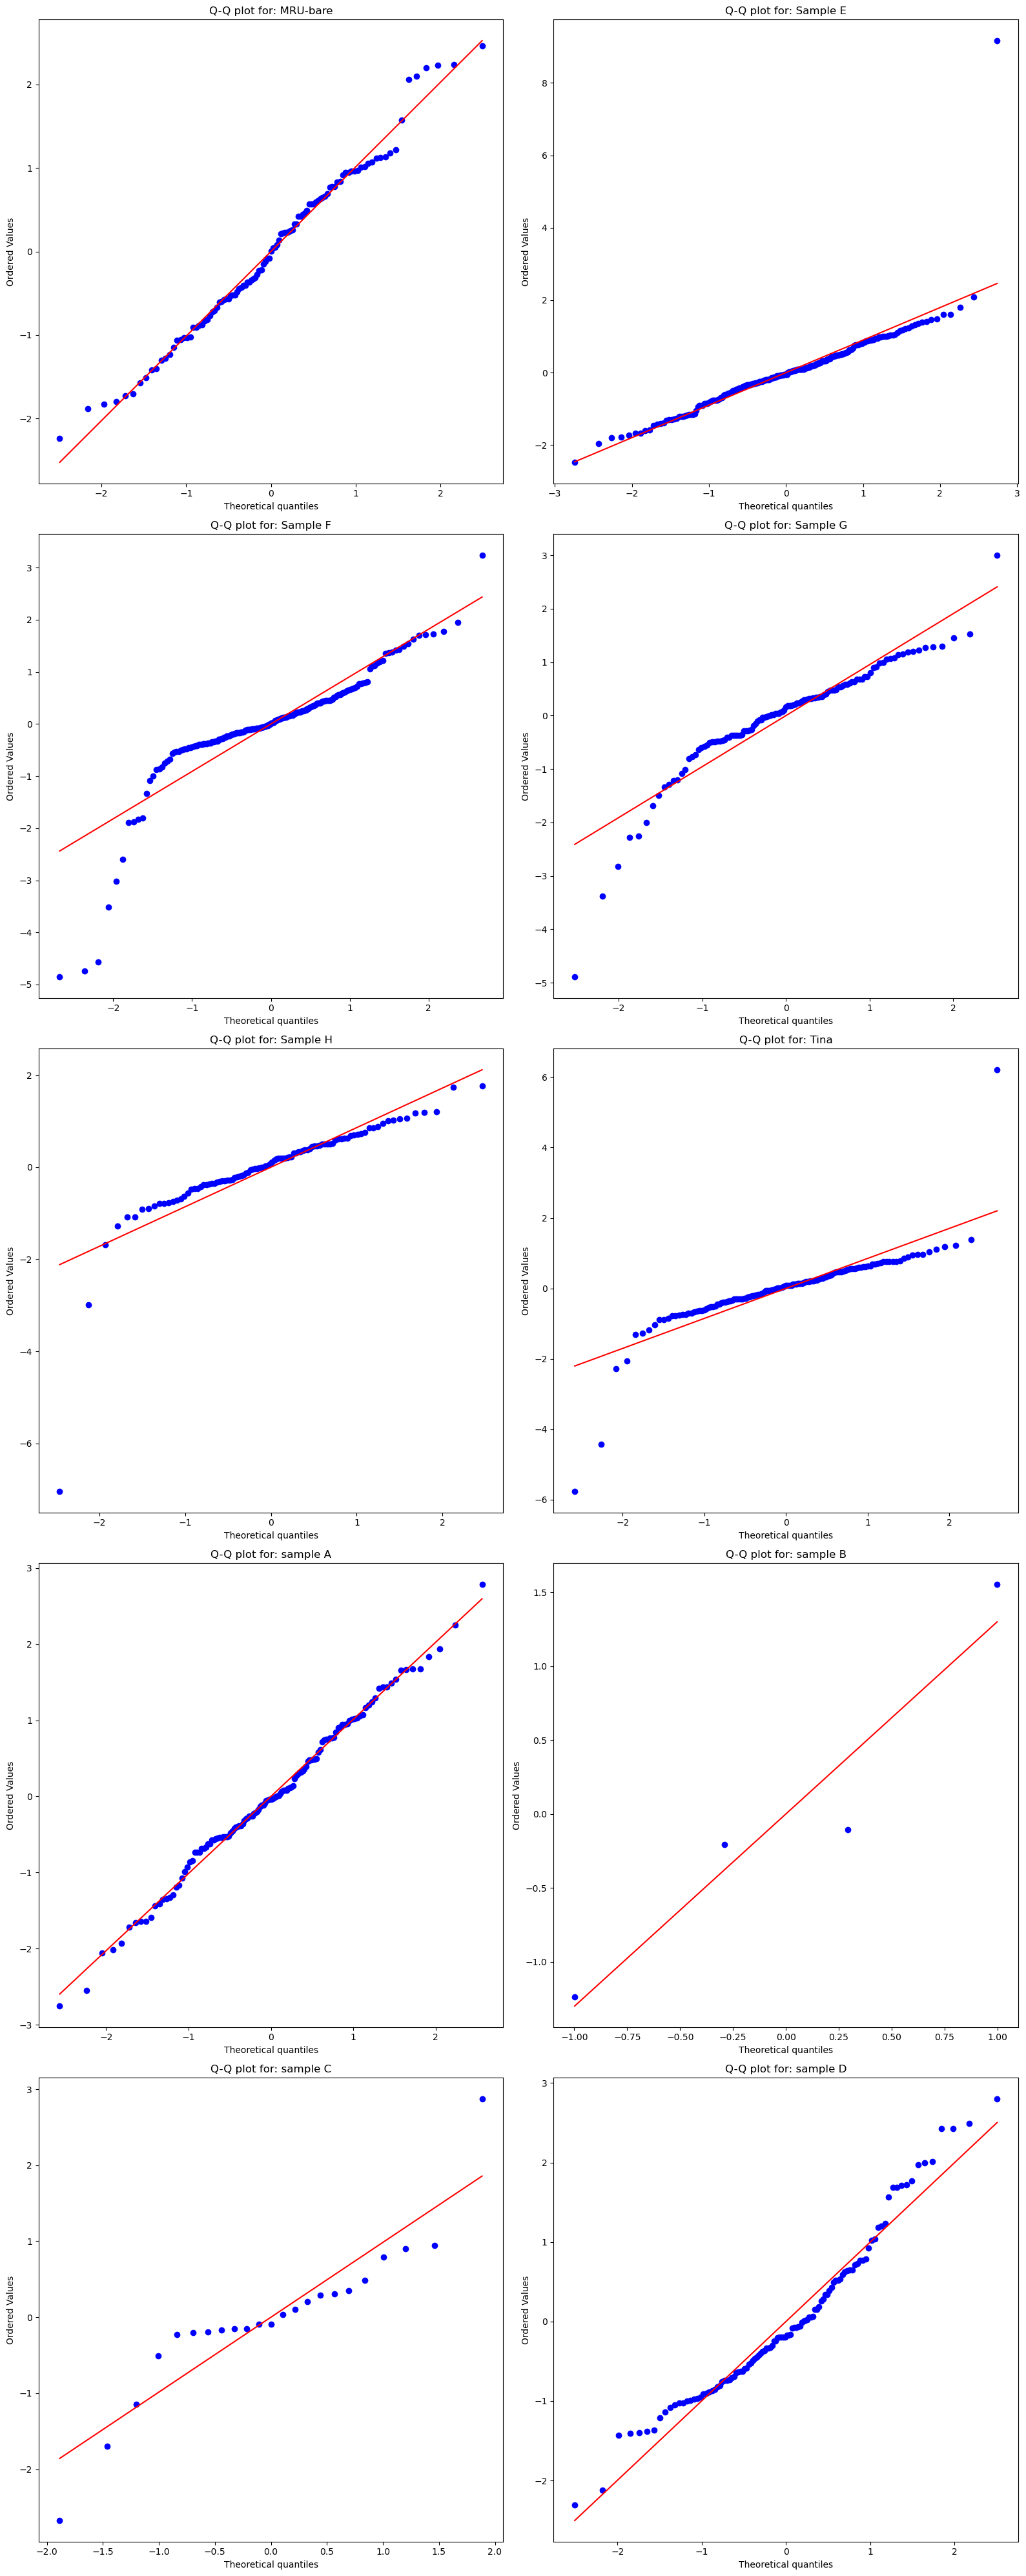

In [116]:
plot_quantiles2(experiment_df)